# Four Runners — Section 5

## Then we checked whether to believe it

> **SIMULATED POPULATION** — Every number below describes the synthetic Run Club Marathon dataset.
> Nothing here is a finding about running, and nothing here is advice.

Sections 1 to 4 took the dataset at face value. This one asks whether it deserves that, and answers
the question from the file itself. All figures reproduce `06_generator.ipynb`; the regression numbers
come from `04_models.ipynb` and `05_report_model.ipynb`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {0: '#5B8FF9', 1: '#61DDAA', 2: '#F6BD16', 3: '#E8684A'}
GREY = '#8C8C8C'
RS = 0


def find_data_dir():
    for candidate in [Path('../data'), Path('data')]:
        if (candidate / 'clean.csv').exists():
            return candidate
    raise FileNotFoundError('clean.csv not found')


DATA = find_data_dir()
df = pd.read_csv(DATA / 'clean.csv')

# drop-outs have no finish time, so they sit out of every model here
d = df[df.dnf == 0]
len(d)

78011

### Which columns actually carry the outcome

A few variables in this file move finish time the way running research would expect. More experience,
faster times. More injuries, slower times. A lower resting heart rate, a faster race. Those are the
three the earlier sections leaned on.

The test below asks what each remaining column is worth: fit the model, shuffle one column, and
measure how much of the explained variance disappears.

In [2]:
# same input set as 06, so the two notebooks report the same numbers
SPOILERS = ['actual_finish_time_minutes', 'target_finish_time_minutes', 'goal_gap', 'dnf',
            'medal', 'medal_outcome', 'runner_id', 'personal_best_minutes']

# one of each mirrored pair: rest_days = 7 - runs_per_week, missed workouts mirror adherence,
# VO2 max mirrors resting heart rate
DUPES = ['rest_days_per_week', 'missed_workout_pct', 'vo2_max']

IN = [c for c in df.select_dtypes('number').columns
      if c not in SPOILERS + DUPES and not c.endswith('_was_missing')]

X, y = d[IN].values, d.actual_finish_time_minutes.values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RS)

# constrained to a sum of per-variable terms: no interactions allowed
additive = HistGradientBoostingRegressor(
    max_iter=300, random_state=RS,
    interaction_cst=[[i] for i in range(X.shape[1])]).fit(Xtr, ytr)

imp = permutation_importance(additive, Xte, yte, n_repeats=3, random_state=RS, scoring='r2')
importance = pd.Series(imp.importances_mean, index=IN).sort_values(ascending=False)

print(f'{(importance <= 0.0005).sum()} of {len(IN)} columns fall below 0.0005')
importance.head(8).round(4).rename('R2 lost when shuffled')

19 of 28 columns fall below 0.0005


running_experience_months    1.0726
injury_count                 0.0512
resting_heart_rate_bpm       0.0246
recovery_score               0.0029
weekly_mileage_miles         0.0017
nutrition_score              0.0013
run_club_attendance_rate     0.0010
training_adherence_pct       0.0009
Name: R2 lost when shuffled, dtype: float64

Running experience is worth roughly thirteen times everything else put together. Injury count and
resting heart rate contribute a little. Below those, **19 of the 28 columns tested fall under a
thousandth of R²**: nutrition, sleep, motivation, recovery, club attendance and the rest of the
wellness block are not weakly informative in this file, they are decorative.

Weekly mileage is among them, worth **0.002 against 1.07 for experience**, and that is the one
that gives the file away. Weekly distance is one of the most consistently reported training determinants of marathon
performance: a meta-analysis of 85 studies covering 137 runner cohorts found weekly distance, runs
per week and longest run all negatively associated with finish time.<sup>1</sup> A dataset in which
it does almost nothing is not a dataset about running. It is a dataset about whatever produced it.

### What produced it

The question turns out to be answerable from the output alone, and three fingerprints settle it.

**The outcome is additive.** Fitting a second model with no constraint on interactions changes R²
by four ten-thousandths, and the sign of that difference moves with the random seed. On 19,500
held-out rows and an unrestricted interaction search, that is indistinguishable from zero: finish
time here is a sum of separate per-variable contributions and nothing else.

In [3]:
unconstrained = HistGradientBoostingRegressor(max_iter=300, random_state=RS).fit(Xtr, ytr)

gain = unconstrained.score(Xte, yte) - additive.score(Xte, yte)
print(f'additive only              R2 = {additive.score(Xte, yte):.4f}')
print(f'interactions allowed       R2 = {unconstrained.score(Xte, yte):.4f}')
print(f'difference                    = {gain:+.4f}')

additive only              R2 = 0.6063
interactions allowed       R2 = 0.6067
difference                    = +0.0004


**What is left over is noise.** If finish time is a sum of contributions plus an error term, the
residuals of a model that recovered those contributions are the error term itself, and its shape is
readable. It is symmetric, normal-tailed, and equally spread across the whole prediction range,
with a standard deviation of 21 minutes.

That figure is also the ceiling on the whole exercise. About 21 minutes of every runner's time in
this file came out of a random number generator, which is why the model in `05` cannot get below an
average error of 18 minutes.

In [4]:
resid = yte - additive.predict(Xte)

print(f'residual SD        {resid.std():.2f} minutes')
print(f'skew               {stats.skew(resid):+.3f}   (0 = symmetric)')
print(f'excess kurtosis    {stats.kurtosis(resid):+.3f}   (0 = normal tails)')

spread = (pd.Series(resid)
            .groupby(pd.qcut(additive.predict(Xte), 5, labels=['fastest', '2', '3', '4', 'slowest']),
                     observed=True)
            .std().round(2))
spread.rename('residual SD by predicted quintile')

residual SD        21.12 minutes
skew               +0.018   (0 = symmetric)
excess kurtosis    -0.015   (0 = normal tails)


fastest    21.19
2          21.01
3          20.80
4          20.87
slowest    21.74
Name: residual SD by predicted quintile, dtype: float64

**The columns were drawn and then clipped.** Almost every variable stops at a round number, and
where the draw ran past the boundary the values pile up on it. Half the runners in this file share
exactly the same weekly mileage; four in five share the same long run. That is the 81% at 15.0 km
behind the decision in `03` to leave `long_run_distance_km` out of the clustering, now with a reason
attached to it.

In [5]:
BOUNDED = ['vo2_max', 'resting_heart_rate_bpm', 'bmi', 'sleep_hours_avg',
           'training_adherence_pct', 'weekly_mileage_miles', 'long_run_distance_km']

bounds = pd.DataFrame({
    'min': df[BOUNDED].min(),
    'max': df[BOUNDED].max(),
    'share at min': (df[BOUNDED] == df[BOUNDED].min()).mean().round(2),
})
bounds

,min,max,share at min
vo2_max,35.0,75.0,0.01
resting_heart_rate_bpm,45.0,80.0,0.00
bmi,18.0,32.0,0.04
sleep_hours_avg,5.0,10.0,0.02
training_adherence_pct,40.0,100.0,0.00
weekly_mileage_miles,12.4,60.2,0.50
long_run_distance_km,15.0,41.2,0.81


### The figure

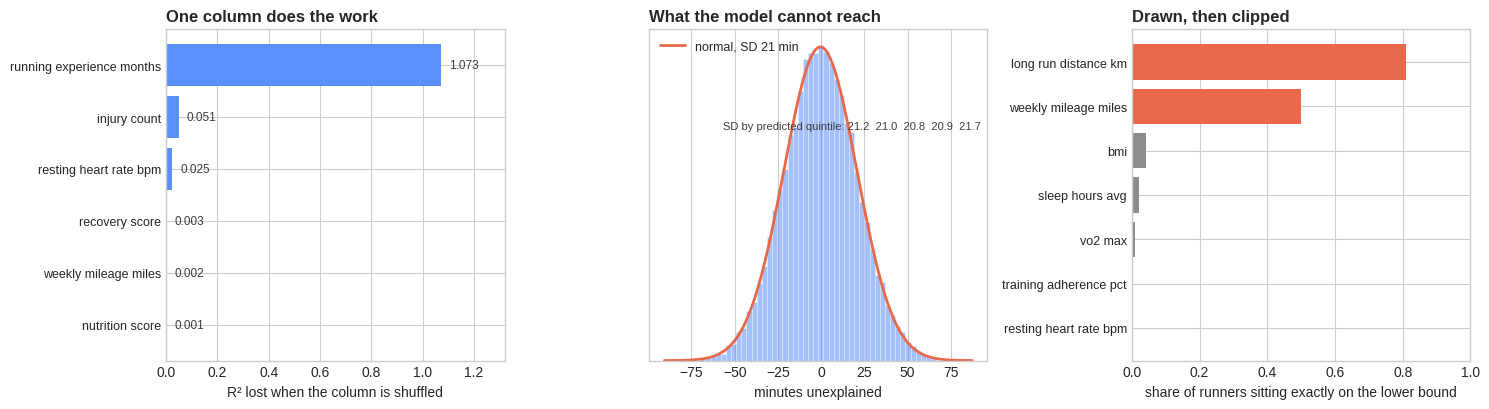

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
fig.patch.set_facecolor('white')

# A — what each column is worth
ax = axes[0]
top = importance.head(6)[::-1]
ax.barh(range(len(top)), top.values,
        color=[COLORS[0] if v > 0.01 else GREY for v in top.values])
for i, v in enumerate(top.values):
    ax.text(v + .03, i, f'{v:.3f}', va='center', fontsize=8.5, color='#3C3C3C')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([c.replace('_', ' ') for c in top.index], fontsize=9)
ax.set_xlim(0, 1.32)
ax.set_xlabel('R² lost when the column is shuffled')
ax.set_title('One column does the work', loc='left', fontweight='bold')

# B — the leftover
ax = axes[1]
ax.hist(resid, bins=60, density=True, color=COLORS[0], alpha=.55, edgecolor='white', linewidth=.4)
grid = np.linspace(resid.min(), resid.max(), 300)
ax.plot(grid, stats.norm.pdf(grid, resid.mean(), resid.std()), color=COLORS[3], lw=2,
        label=f'normal, SD {resid.std():.0f} min')
ax.set_xlabel('minutes unexplained')
ax.set_yticks([])
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.text(.98, .70, 'SD by predicted quintile: ' + '  '.join(f'{v:.1f}' for v in spread),
        transform=ax.transAxes, ha='right', fontsize=8, color='#3C3C3C')
ax.set_title('What the model cannot reach', loc='left', fontweight='bold')

# C — the clipping
ax = axes[2]
share = bounds['share at min'].sort_values()
ax.barh(range(len(share)), share.values,
        color=[COLORS[3] if v > .2 else GREY for v in share.values])
ax.set_yticks(range(len(share)))
ax.set_yticklabels([c.replace('_', ' ') for c in share.index], fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('share of runners sitting exactly on the lower bound')
ax.set_title('Drawn, then clipped', loc='left', fontweight='bold')

fig.tight_layout()
Path('../figures').mkdir(exist_ok=True)
fig.savefig('../figures/section5_generator.png', dpi=150, bbox_inches='tight')
plt.show()

### What this section is worth

The process is consistent with one description: draw each column independently from a bounded
distribution and clip it, derive a handful of columns from others, compute finish time as a sum of
separate contributions dominated by running experience, add Gaussian noise of about 21 minutes, and
obtain the target time by subtracting a random amount from the result.

That single sentence accounts for four things that were separate puzzles until now. Most columns are
flat against finish time because they were never in the equation. The drivers do not differ by
profile because an additive process has no interactions to find. No model beats 18 minutes because
21 of them are random. And nobody beats their target because the target was derived from the finish
time rather than set before the race.

None of this makes Sections 1 to 4 false. They describe the file accurately. It does mean the file
describes itself, and not marathon running.

---

<sup>1</sup> Doherty C, Keogh A, Davenport J, Lawlor A, Smyth B, Caulfield B. An evaluation of the
training determinants of marathon performance: a meta-analysis with meta-regression. *Journal of
Science and Medicine in Sport*, 2020;23(2):182–188. doi:10.1016/j.jsams.2019.09.013

### Handoff to Section 6

> A synthetic dataset can produce four plausible runners, a believable improvement curve and a
> drop-out pattern that looks like real life. It can also say that weekly mileage is nearly
> irrelevant, which is false about running and true about the file. The closing section holds both
> halves of that sentence together.